In [1]:
import pandas as pd

data = {
    "timestamp": [
        "2024-01-01 10:00:00", "2024-01-01 10:05:00",
        "2024-01-01 10:10:00", "2024-01-01 10:15:00",
        "2024-01-01 10:20:00", "2024-01-02 11:00:00",
        "2024-01-02 11:10:00", "2024-01-02 11:20:00"
    ],
    "level": ["INFO", "ERROR", "INFO", "WARNING", "ERROR", "INFO", "ERROR", "INFO"],
    "service": ["Auth", "DB", "API", "Auth", "API", "DB", "Auth", "API"],
    "message": [
        "Service started", "Connection failed", "Request processed",
        "Token expired", "Timeout occurred", "Connection success",
        "Login failed", "Response sent"
    ]
}

df = pd.DataFrame(data)
df.to_csv('logs.csv', index=False)

df.head()

,timestamp,level,service,message
0,2024-01-01 10:00:00,INFO,Auth,Service started
1,2024-01-01 10:05:00,ERROR,DB,Connection failed
2,2024-01-01 10:10:00,INFO,API,Request processed
3,2024-01-01 10:15:00,WARNING,Auth,Token expired
4,2024-01-01 10:20:00,ERROR,API,Timeout occurred


In [2]:
df = pd.read_csv('logs.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()

,timestamp,level,service,message
0,2024-01-01 10:00:00,INFO,Auth,Service started
1,2024-01-01 10:05:00,ERROR,DB,Connection failed
2,2024-01-01 10:10:00,INFO,API,Request processed
3,2024-01-01 10:15:00,WARNING,Auth,Token expired
4,2024-01-01 10:20:00,ERROR,API,Timeout occurred


In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Missing Values:
 timestamp    0
level        0
service      0
message      0
dtype: int64

Data Types:
 timestamp    datetime64[ns]
level                object
service              object
message              object
dtype: object


In [4]:
error_df = df[df['level'] == 'ERROR']

print("Total Errors:", error_df.shape[0])

Total Errors: 3


In [5]:
errors_by_service = error_df.groupby('service').size()
print(errors_by_service)

service
API     1
Auth    1
DB      1
dtype: int64


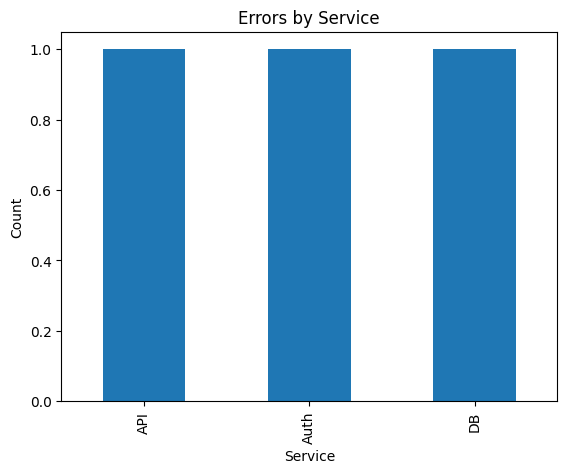

In [6]:
import matplotlib.pyplot as plt

errors_by_service.plot(kind='bar')
plt.title("Errors by Service")
plt.xlabel("Service")
plt.ylabel("Count")
plt.show()

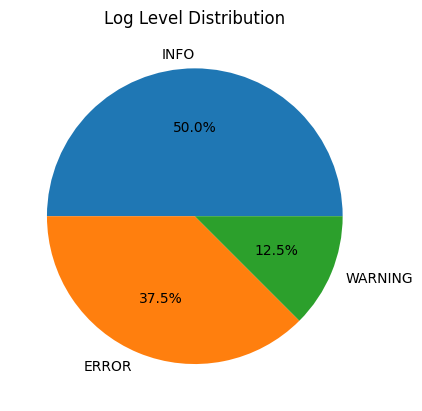

In [7]:
df['level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Log Level Distribution")
plt.ylabel("")
plt.show()

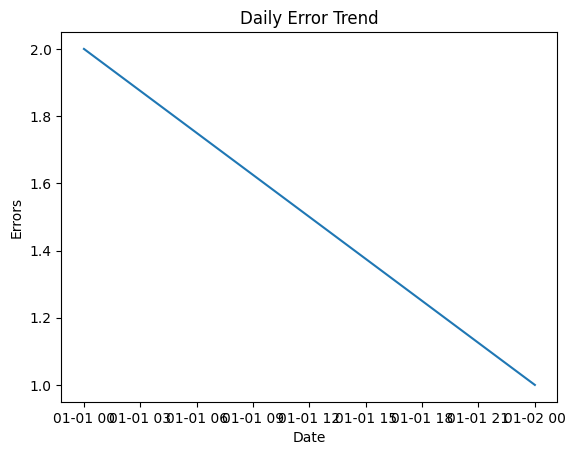

In [8]:
df['date'] = df['timestamp'].dt.date
daily_errors = error_df.groupby(df['date']).size()

daily_errors.plot()
plt.title("Daily Error Trend")
plt.xlabel("Date")
plt.ylabel("Errors")
plt.show()

In [9]:
error_df.to_csv('error_logs.csv', index=False)